# UCI Dataset: Connectionist Bench (Sonar, Mines vs. Rocks)

In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))

import random

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset

from sklearn.preprocessing import LabelEncoder
from ucimlrepo import fetch_ucirepo

from sklearn.neighbors import KernelDensity

from tqdm import tqdm

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from joblib import Parallel, delayed

import ld
from utils import vectorize_tensor, reconstruct_tensor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Setup

### General

In [2]:
def set_random_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    cp.random.seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_random_seed(40)
k = 2
bandwidth = 0.05
bandwidth_AE = 0.05
eps = np.asarray(1.0e-5)

### Dataset

In [3]:
class NumpyDataset(Dataset):
    def __init__(self, features, labels, transform=None):
        """
        Args:
            features (np.ndarray): Feature matrix.
            labels (np.ndarray): Label array.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        sample = self.features[idx]
        label = self.labels[idx]

        if self.transform:
            sample = self.transform(sample)

        return sample, label

# Normalize transform for UCI dataset
class Normalize:
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean, dtype=torch.float32)
        self.std = torch.tensor(std, dtype=torch.float32)

    def __call__(self, sample):
        # std is 0 for constant features, so we add a small epsilon to avoid division by zero
        return (sample - self.mean) / (self.std + eps)

# Custom transformation for adding Gaussian noise
class AddGaussianNoise:
    def __init__(self, mean=0.0, std=0.1):
        self.mean = mean
        self.std = std

    def __call__(self, sample):
        noise = torch.randn_like(sample) * self.std + self.mean
        return sample + noise

# Composite transformation to combine Normalize and AddGaussianNoise
class CompositeTransform:
    def __init__(self, transforms):
        """
        Args:
            transforms (list): List of transformations to apply in sequence.
        """
        self.transforms = transforms

    def __call__(self, sample):
        for transform in self.transforms:
            sample = transform(sample)
        return sample

In [4]:
UCI_id = 151 # https://archive.ics.uci.edu/dataset/151/connectionist+bench+sonar+mines+vs+rocks
test_size = 0.2

UCI_dataset = fetch_ucirepo(id=UCI_id)

X = np.array(UCI_dataset.data.features)
Y = np.array(LabelEncoder().fit_transform(UCI_dataset.data.targets))

# normalize to [0, 1]
X = (X - X.min()) / (X.max() - X.min())

# Find unique labels
unique_labels = np.unique(Y)

# Create an array of indices
indices = np.arange(len(Y))
np.random.shuffle(indices)

# Use the shuffled indices to randomly select data for training and testing
n_train = int(len(Y) * (1 - test_size))
X_train, Y_train = X[indices[:n_train]], Y[indices[:n_train]]
X_test, Y_test = X[indices[n_train:]], Y[indices[n_train:]]

X_train_class = []
Y_train_class = []
for i in unique_labels:
    X_train_class.append(X_train[np.isin(Y_train, i).flatten()])
    Y_train_class.append(Y_train[np.isin(Y_train, i).flatten()])

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

train_dataset = NumpyDataset(X_train, Y_train, transform=Normalize(mean, std))
test_dataset = NumpyDataset(X_test, Y_test, transform=Normalize(mean, std))

In [5]:
D = X_train.shape[1]
S = (2, 2, 3, 5)

if np.prod(S) != D:
    raise ValueError("The product of the tensor structure is not equal to the feature dimension")

new_sample_size_per_class = int(n_train * 0.2 // len(unique_labels))

# Print dataset statistics
print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")
print(f"New sample size: {new_sample_size_per_class * len(unique_labels)}")
print(f"Number of classes: {len(unique_labels)}")
print(f"Number of features: {D}")

Train size: 166
Test size: 42
New sample size: 32
Number of classes: 2
Number of features: 60


## Pseudo-Non-Linear Data Augmentation

### Legendre Decomposition (Many-Body Approximation)

In [6]:
B_LD = ld.default_B(S, 1, cp.get_array_module(X_train[0]))
print(f"Dimension of Base Sub-Manifold: {B_LD.shape[0]}")

scaleX_class = []
theta_class = []

def LD_helper(i, class_):
    _, _, scaleX, _, theta = ld.LD(X_train_class[class_][i].reshape(*S), B=B_LD, verbose=False, n_iter=1000, lr=1e-1)
    return (scaleX, theta)

results = Parallel(n_jobs=30)(delayed(LD_helper)(i, class_) for class_ in unique_labels for i in range(len(X_train_class[class_])))

len_class = 0
for class_ in unique_labels:
    scaleX_list = []
    theta_list = []

    for i in range(len(X_train_class[class_])):
        result = results[i + len_class]

        scaleX_list.append(result[0])
        theta_list.append(result[1])

    len_class += len(X_train_class[class_])

    scaleX_class.append(scaleX_list)
    theta_class.append(theta_list)

Dimension of Base Sub-Manifold: 9


#### Fitting on Projected Points

In [7]:
sampled_theta_class = []

for class_ in unique_labels:
    reduced_theta = vectorize_tensor(np.array(theta_class[class_]), B_LD)

    # Fit a KDE to the theta values
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(reduced_theta)
    # Sample new data from the KDE
    sampled_reduced_theta = kde.sample(n_samples=new_sample_size_per_class)

    sampled_theta = reconstruct_tensor(sampled_reduced_theta, (new_sample_size_per_class, *S), B_LD)

    sampled_theta_class.append(sampled_theta)

#### Construct Local Data Sub-Manifold

In [8]:
# Construct the constrained coordinates
B_BP = ld.default_B(S, 2, cp.get_array_module(X_train[0]))
print(f"Dimension of Local Data Sub-Manifold: {D - B_BP.shape[0]}")

# Compute every datapoint's eta_hat (served as the linear constraints)
eta_hat_class = []

for class_ in unique_labels:
    eta_hat_list = []
    for i in range(X_train_class[class_].shape[0]):
        xp = cp.get_array_module(X_train_class[class_][i])
        P = (X_train_class[class_][i].reshape(*S) + eps) / scaleX_class[class_][i]
        eta_hat = ld.get_eta(P, len(S), xp)
        eta_hat_list.append(eta_hat)
    eta_hat_list = cp.asarray(eta_hat_list)

    eta_hat_class.append(eta_hat_list)

Dimension of Local Data Sub-Manifold: 30


#### Backward Projection

In [9]:
def BP_helper(i, class_):
    N = ld.kNN(sampled_theta_class[class_][i], np.array(theta_class[class_]), k=k)
    avg_scale = np.mean(np.array(scaleX_class[class_])[N])
    avg_eta_hat = np.mean(eta_hat_class[class_][N], axis=0)

    _, _, P, theta = ld.BP(sampled_theta_class[class_][i], [(X_train_class[class_][j].reshape(*S) + eps) / scaleX_class[class_][j] for j in N], avg_eta_hat, avg_scale, B=B_BP, verbose=False, n_iter=1000, lr=5e-2, exit_abs=True)
    X_recons_ = P.reshape(-1)
    return (theta, X_recons_)

results = Parallel(n_jobs=30)(delayed(BP_helper)(i, class_) for i in range(new_sample_size_per_class) for class_ in unique_labels)

sampled_theta_BP_class = []
sampled_X_BP_class = []

for class_ in unique_labels:
    sampled_theta_BP = []
    sampled_X_BP = []
    for i in range(new_sample_size_per_class):
        result = results[i + new_sample_size_per_class * class_]

        sampled_theta_BP.append(result[0])
        sampled_X_BP.append(result[1])

    sampled_theta_BP_class.append(np.array(sampled_theta_BP))
    sampled_X_BP_class.append(np.array(sampled_X_BP))

## Data Augmentation with Autoencoder

In [10]:
class Encoder(nn.Module):
    def __init__(self, input_size=D, hidden_size=B_LD.shape[0], z_dim=3):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, z_dim)
        self.relu = nn.ReLU()
    def forward(self , x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class Decoder(nn.Module):
    def __init__(self, output_size=D, hidden_size=B_LD.shape[0], z_dim=3):
        super().__init__()
        self.fc1 = nn.Linear(z_dim , hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
    def forward(self , x):
        x = self.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

100%|██████████| 200/200 [00:11<00:00, 16.88it/s]


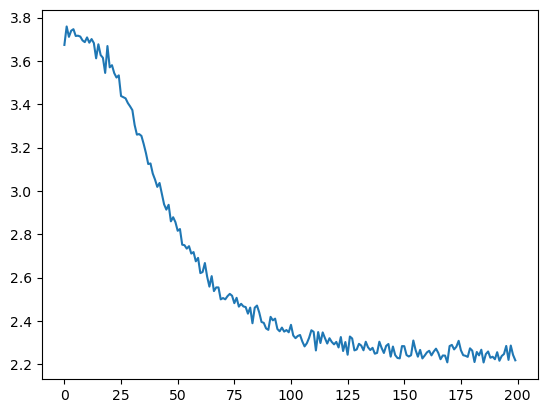

In [11]:
train_loader_original = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

enc = Encoder().to(device)
dec = Decoder().to(device)
loss_fn = nn.MSELoss()
optimizer_enc = torch.optim.Adam(enc.parameters())
optimizer_dec = torch.optim.Adam(dec.parameters())

train_loss = []
num_epochs = 200

for epoch in tqdm(range(num_epochs)):
    train_epoch_loss = 0
    for (x , _) in train_loader_original:
        x = x.to(device)
        x = x.flatten(1)
        latents = enc(x)
        output = dec(latents)
        loss = loss_fn(output , x)
        train_epoch_loss += loss.cpu().detach().numpy()
        optimizer_enc.zero_grad()
        optimizer_dec.zero_grad()
        loss.backward()
        optimizer_enc.step()
        optimizer_dec.step()
    train_loss.append(train_epoch_loss)
plt.plot(train_loss)

In [12]:
representation = None
all_labels = []

with torch.no_grad():
    for (xs , labels) in train_loader_original:
        xs = xs.to(device)
        xs = xs.flatten(1)
        all_labels.extend(list(labels.numpy()))
        latents = enc(xs)
        if representation is None:
            representation = latents.cpu()
        else:
            representation = torch.vstack([representation , latents.cpu()])

all_labels = np.array(all_labels)
representation = representation.numpy()

In [13]:
sampled_X_AE_class = []

for class_ in unique_labels:
    sampled_X_AE_list = []

    rep = representation[np.argwhere(all_labels == class_)].squeeze()
    # Fit a KDE to the theta values
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth_AE).fit(rep)

    # Sample new data from the KDE
    sampled_rep = kde.sample(n_samples=new_sample_size_per_class)
    for i in range(new_sample_size_per_class):
        pred = dec(torch.Tensor(sampled_rep[i])[None , ...].to(device)).cpu().detach().numpy()
        sampled_X_AE_list.append(pred.flatten())

    sampled_X_AE_class.append(sampled_X_AE_list)

## Classification Performance

#### Dataset Preparation

In [14]:
# Helper function to create a DataLoader for augmented datasets
def prepare_augmented_dataset(original_dataset, augmented_data, augmented_labels, transform, batch_size):
    # Create dataset from augmented data
    augmented_dataset = NumpyDataset(features=augmented_data, labels=augmented_labels, transform=transform)

    # Combine with the original dataset
    combined_dataset = ConcatDataset([original_dataset, augmented_dataset])

    # Create a DataLoader for the combined dataset
    return DataLoader(dataset=combined_dataset, batch_size=batch_size, shuffle=True)

# Main function to prepare datasets and loaders
def create_datasets_and_loaders(batch_size=64):
    # Define transformations
    transform_standard = CompositeTransform([
        Normalize(mean, std),
        AddGaussianNoise(mean=0.0, std=std.min()/4)  # Add Gaussian noise with 1/4 of the standard deviation
    ])
    transform_none = Normalize(mean, std)

    train_standard = NumpyDataset(X_train, Y_train, transform=transform_standard)
    train_none = NumpyDataset(X_train, Y_train, transform=transform_none)

    augmented_data_PNL = []
    labels_PNL = []
    augmented_data_AE = []
    labels_AE = []

    for class_ in range(len(unique_labels)):
        for data_PNL in sampled_X_BP_class[class_]:
            augmented_data_PNL.append(data_PNL)
            labels_PNL.append(class_)

        for data_AE in sampled_X_AE_class[class_]:
            augmented_data_AE.append(data_AE)
            labels_AE.append(class_)

    augmented_data_PNL = np.array(augmented_data_PNL)
    labels_PNL = np.array(labels_PNL)
    augmented_data_AE = np.array(augmented_data_AE)
    labels_AE = np.array(labels_AE)

    mean_LD = augmented_data_PNL.mean(axis=0)
    std_LD = augmented_data_PNL.std(axis=0)
    transform_none_LD = Normalize(mean_LD, std_LD)

    mean_AE = augmented_data_AE.mean(axis=0)
    std_AE = augmented_data_AE.std(axis=0)
    transform_none_AE = Normalize(mean_AE, std_AE)

    # Combine original with augmented data
    train_loader_PNL = prepare_augmented_dataset(train_none, augmented_data_PNL, labels_PNL, transform_none_LD, batch_size)
    train_loader_AE = prepare_augmented_dataset(train_none, augmented_data_AE, labels_AE, transform_none_AE, batch_size)

    # DataLoader for the original dataset only
    train_loader_standard = DataLoader(train_standard, batch_size=batch_size, shuffle=True)
    train_loader_none = DataLoader(train_none, batch_size=batch_size, shuffle=True)

    return {
        "standard": train_loader_standard,
        "none": train_loader_none,
        "PNL_augmented": train_loader_PNL,
        "AE_augmented": train_loader_AE,
    }

loaders = create_datasets_and_loaders(batch_size=16)

# Check each DataLoader
for name, loader in loaders.items():
    print(f"{name} loader:")
    for images, labels in loader:
        print(f"Images shape: {images.shape}, Labels shape: {labels.shape}")
        break

train_loader_standard = loaders["standard"]
train_loader_none = loaders["none"]
train_loader_PNL = loaders["PNL_augmented"]
train_loader_AE = loaders["AE_augmented"]

standard loader:
Images shape: torch.Size([16, 60]), Labels shape: torch.Size([16])
none loader:
Images shape: torch.Size([16, 60]), Labels shape: torch.Size([16])
PNL_augmented loader:
Images shape: torch.Size([16, 60]), Labels shape: torch.Size([16])
AE_augmented loader:
Images shape: torch.Size([16, 60]), Labels shape: torch.Size([16])


### MLP Model

One-layer (effectively a logistic regression) due to the simplicity of the dataset.

In [15]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size=10, num_classes=len(unique_labels)):
        super(MLP, self).__init__()
        self.input_size = input_size
        self.hidden_layer = nn.Linear(input_size, hidden_size)
        self.output_layer = nn.Linear(hidden_size, num_classes)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, self.input_size)  # Flatten the input
        x = self.activation(self.hidden_layer(x))  # Apply hidden layer + ReLU
        x = self.output_layer(x)  # Apply output layer
        return x

# Training Function
def train_model(model, train_loader, criterion, optimizer, scheduler, num_epochs, device='cuda'):
    train_loss = []
    model.to(device)
    for epoch in tqdm(range(num_epochs)):
        model.train()
        train_epoch_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_epoch_loss += loss.item()

        scheduler.step()
        train_loss.append(train_epoch_loss)

    plt.plot(train_loss)

def test_model(model, test_loader, device='cuda'):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for features, labels in test_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

def bootstrapping(train_loader, test_dataset, num_epochs=10, learning_rate=1e-1, n_bootstrap=20, device='cuda'):
    """
    Train the Logistic Regression model on the training dataset, and evaluate it using bootstrapping on the test dataset.

    Args:
        train_loader: DataLoader for training data.
        test_dataset: Dataset object for the test data.
        num_epochs: Number of epochs for training.
        learning_rate: Learning rate for the optimizer.
        device: Device to run the training on ('cuda' or 'cpu').

    Returns:
        Prints the mena accuracy and its standard deviation after bootstrapping.
    """
    # Initialize the model, loss, and optimizer
    model = MLP(input_size=D, num_classes=len(unique_labels)).to(device)
    criterion = nn.CrossEntropyLoss()
    # optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)  # Decay LR every 30 epochs

    # Train the model
    train_model(model, train_loader, criterion, optimizer, scheduler, num_epochs=num_epochs, device=device)

    # Perform bootstrapping
    accuracies = []

    num_test_samples = len(test_dataset) // 2
    for i in range(n_bootstrap):
        indices = torch.randint(len(test_dataset), size=(num_test_samples,))
        bootstrap_subset = Subset(test_dataset, indices)
        bootstrap_loader = DataLoader(dataset=bootstrap_subset, batch_size=num_test_samples, shuffle=False)

        accuracy = test_model(model, bootstrap_loader, device=device)
        accuracies.append(accuracy)

    # Compute statistics
    mean_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)

    print(f"Mean accuracy: {mean_accuracy:.2f}%")
    print(f"Standard deviation: {std_accuracy:.2f}")

### Dataset Performance

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:09<00:00,  5.10it/s]


Mean accuracy: 78.81%
Standard deviation: 11.22


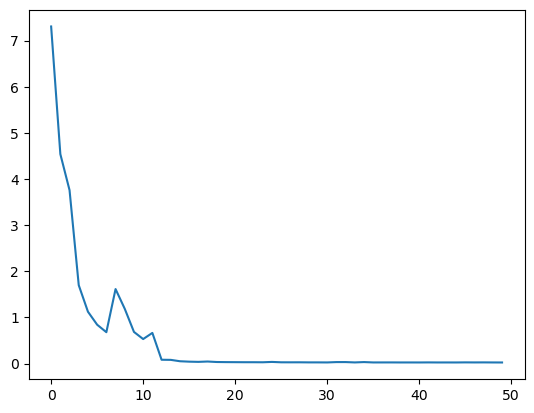

In [16]:
bootstrapping(train_loader_none, test_dataset, num_epochs=50, learning_rate=0.1, device=device)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:10<00:00,  4.65it/s]


Mean accuracy: 75.00%
Standard deviation: 9.97


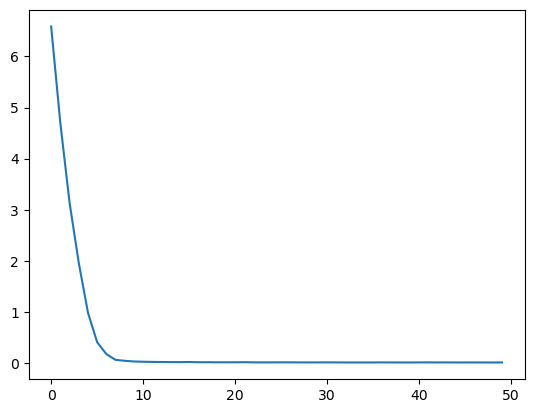

In [17]:
bootstrapping(train_loader_standard, test_dataset, num_epochs=50, learning_rate=0.1, device=device)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:11<00:00,  4.32it/s]


Mean accuracy: 80.00%
Standard deviation: 6.49


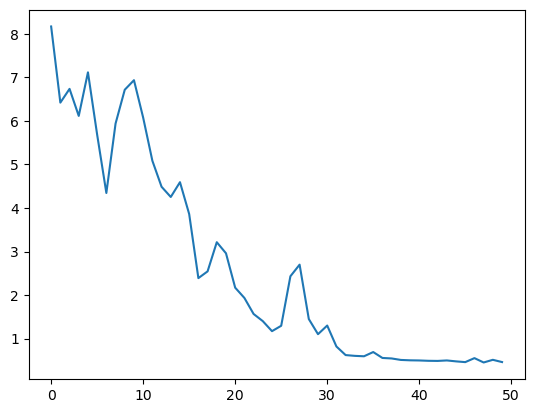

In [18]:
bootstrapping(train_loader_PNL, test_dataset, num_epochs=50, learning_rate=0.1, device=device)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:11<00:00,  4.25it/s]


Mean accuracy: 79.29%
Standard deviation: 9.44


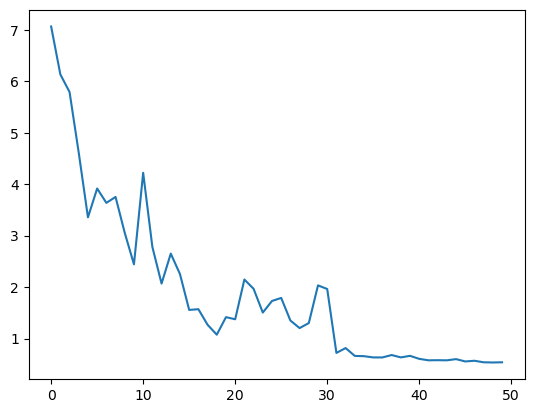

In [19]:
bootstrapping(train_loader_AE, test_dataset, num_epochs=50, learning_rate=0.1, device=device)